## Notes for this document / model


other things one could do in the future:
1. Test/train split:  note that we cannot perform a random splitting anymore as trivially, as the 7d sum values quickly introduce data leakage into model training. I think it is ok to not care about this 
2. Check: do missing y values indicate 0 cases, i.e. can we fill missing values after a certain time?


In [1]:
import jax.random as jr
import jax.numpy as jnp
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import optimization_utils

In [2]:
%config InlineBackend.print_figure_kwargs = {'dpi': 110, 'bbox_inches': 'tight'}

In [3]:
config = {
        # General settings
        "seed": 0,  # random seed

        # data selection settings
        "data_kwargs": {
            "town": "Bonn",
            "sampling_area": "North_South",
            "project": "both", # one of ESI_CorA, AMELAG
            "max_precipitation_subsetting": None, # one of None, dry, light_rain
            "substance_normalization": "flow", # one of None, PMMoV, flow
            "gene_target": "N1", # one of N1, N2
            "log_scale": True, # this only considers WW measurements, not case counts
        },

        "E0": 862.857, 
        "I0": 1294.286,
        "R0": 162092.04, # 92% of pop, based on https://www.rki.de/DE/Themen/Infektionskrankheiten/Infektionskrankheiten-A-Z/C/COVID-19-Pandemie/AK-Studien/Ergebnisse.html
        
        "T_max": 21,

        "lr_strategy": (1e-3, 
                        1e-4, 
                        1e-4,
                        1e-5), # lr for each strategy (1e-4, 5e-5, 3e-5, 1e-5),
        "steps_strategy": (2000, 
                        2000, 
                        3000, 
                        4000), # epochs for each strategy
        "phase_cut_date": "2023-03-14", 
        "dt": 0.2,    
}

In [4]:
config = {
        # General settings
        "seed": 0,  # random seed

        # data selection settings
        "data_kwargs": {
            "town": "Bonn",
            "pathogen": "influenza"
        },

        "T_max": 21,

        "lr_strategy": (1e-5, 
                        1e-4, 
                        1e-4,
                        1e-5), # lr for each strategy (1e-4, 5e-5, 3e-5, 1e-5),
        "steps_strategy": (2000, 
                        2000, 
                        3000, 
                        4000), # epochs for each strategy
        "phase_cut_date": "2024-02-14", 
        "dt": 0.2,    
}

data = optimization_utils.two_phase_integrative_model_load_data(config)

config["E0"] = data["population_size"] * 1e-4
config["I0"] = data["population_size"] * 1e-4
config["R0"] = 0.3 * data["population_size"] # recent infection and/or cross-protective antibodies + vaccination


In [4]:
config["T_peak_init"] = 4.0  # peak time in days

In [5]:
config["width_size"] = 8
config["depth"] = 3
config["activation"] = "tanh"  # Smooth activation for continuous dynamics
config["n_freqs"] = 0 # 3  # Number of Fourier features for underreporting
config["solver"] = "Tsit5"
config["solver_kwargs"] = {
    "atol": 1e-6,
    "rtol": 1e-6
}
config["k1_init"] = 1.0 # initial shedding curve parameters
config["k2_init"] = 0.8
config["k3_init"] = 0.8

config["init_par_vmr"] = 1.1  # initial value for VMR of cases
config["init_sigma_C"] = 1.0  # initial value for the log‐noise of concentration
config["reporting_delay"] = 1  # days, delay between infection and reporting

config["regularization_mode"] = "beta_derivative" # one of L2, beta_derivative or None
config["reg_norm"] = 1e-6

config["n_days_pred_conc"] = 0 # days to predict beyond last observed date for concentration

In [6]:
# logging of optimization routine
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import model_definition.two_phase_integrative_ude as two_phase_integrative_ude
import data.data_utils_integrative_model as data_utils_integrative_model


In [7]:
y_name, obs_dates, t_scale, obs_day_idx, ys, population_size, prevalence = data_utils_integrative_model.load_data(config["data_kwargs"], t_normalized=False)

In [8]:
ys

array([[  11.66907501,           nan],
       [  11.73209286, 3020.        ],
       [          nan, 3632.        ],
       ...,
       [          nan,   90.        ],
       [          nan,   84.        ],
       [   7.97505379,           nan]], shape=(564, 2))

In [9]:
prevalence

In [10]:
experiment_log_dir, writer = optimization_utils.define_experiment_logger(
        config=config,
        experiment_series="two_phase_integrative_ude",
        experiment_name="test",
    )

model, total_nll, train_nll, val_nll, train_loss = optimization_utils.two_phase_integrative_model_train_and_evaluate(config, writer, experiment_log_dir, print_every=100)

Logging to results/two_phase_integrative_ude/test
Training stage_1 with learning rate 0.001 for 2000 steps
Within beta: beta_derivative
Within underreporting: None
Step: 0, Loss: 859.8778686523438
Within beta: beta_derivative
Within underreporting: None
Within beta: beta_derivative
Within underreporting: None
Step: 100, Loss: 241.2183380126953
Step: 200, Loss: 79.73588562011719
Step: 300, Loss: 71.90914154052734
Step: 400, Loss: 64.04918670654297
Step: 500, Loss: 60.29977035522461
Step: 600, Loss: 55.45305252075195
Step: 700, Loss: 48.846378326416016
Step: 800, Loss: 42.84609603881836
Step: 900, Loss: 38.80461502075195
Step: 1000, Loss: 36.136383056640625
Step: 1100, Loss: 34.208778381347656
Step: 1200, Loss: 32.71446228027344
Step: 1300, Loss: 31.47440528869629
Step: 1400, Loss: 30.39835548400879
Step: 1500, Loss: 29.402542114257812
Step: 1600, Loss: 28.477609634399414
Step: 1700, Loss: 27.664325714111328
Step: 1800, Loss: 26.992040634155273
Step: 1900, Loss: 26.442228317260742
Step: 

In [9]:
config = {
        # General settings
        "seed": 1,  # random seed

        # data selection settings
        "data_kwargs": {
            "town": "Bonn",
            "pathogen": "influenza",
        },
        
        "dt": 0.2,
        "T_max": 25, # dummy value
}
config["E0"] = data["population_size"] * 1e-4
config["I0"] = data["population_size"] * 1e-4
config["phase_cut_date"] = "2024-02-14"

hp_config = {'width_size': 16, 'depth': 3, 'activation': 'tanh', 'n_freqs': 3, 'T_max': 25, 'T_peak_init': 4.998493582104203, 
             'k1_init': 0.03365630028533706, 'k2_init': 2.47749021365855, 'k3_init': 0.3527457315474798, 'init_par_vmr': 1.5435626189340022, 
             'init_sigma_C': 0.17994006550103564, 'reporting_delay': 3, 'solver': 'Tsit5', 'rtol': 2.7739039205920443e-06, 
             'atol': 5.241784462753781e-06, 'lr_step1': 0.0002005022586860716, 'lr_step2': 0.00016340900244011668, 
             'lr_step3': 3.877393837706866e-05, 'lr_step4': 7.708575046957178e-05, 'step1': 584, 'step2': 1534, 'step3': 2942, 
             'step4': 3865, 'regularization_mode': 'beta_derivative', 'reg_norm': 9.037278850159714e-05, 
             'underreporting_regularization_mode': 'derivative', 'underreporting_reg_norm': 7.428198292703683e-05, 
             'R0_multiplier': 0.32207560899740756}
hp_config["lr_strategy"] = (hp_config["lr_step1"], hp_config["lr_step2"], hp_config["lr_step3"], hp_config["lr_step4"])
hp_config["steps_strategy"] = (hp_config["step1"], hp_config["step2"], hp_config["step3"], hp_config["step4"])

hp_config["solver_kwargs"] = {"rtol": hp_config["rtol"], "atol": hp_config["atol"]}
hp_config["R0"] = hp_config["R0_multiplier"]*data["population_size"]
hp_config.update(config)

In [10]:
experiment_log_dir, writer = optimization_utils.define_experiment_logger(
        config=config,
        experiment_series="two_phase_integrative_ude",
        experiment_name="test",
    )

model, total_nll, train_nll, val_nll, train_loss = optimization_utils.influenza_integrative_model_train_and_evaluate(config, writer, experiment_log_dir, print_every=100)

Logging to results/two_phase_integrative_ude/test


/home/iru-mls/Documents/repositories/ww_bonn_jax/model_definition/two_phase_integrative_ude.py:99: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.rhs = UDE_rhs(state_dim, width_size, depth, activation, n_freqs, t_scale, population_size, key=key)
/home/iru-mls/Documents/repositories/ww_bonn_jax/model_definition/two_phase_integrative_ude.py:407: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.UDE = NeuralUDE(1, width_size, depth, activation, n_freqs, t_scale, population_size,


Training stage_1 with learning rate 1e-05 for 2000 steps
Within beta: beta_derivative
Within underreporting: None
Within beta: beta_derivative
Within underreporting: None
Within beta: beta_derivative
Within underreporting: None
Training stage_2 with learning rate 0.0001 for 2000 steps
Training stage_3 with learning rate 0.0001 for 3000 steps
Training stage_4 with learning rate 1e-05 for 4000 steps


In [12]:
t_all, t_phase_1, t_mask_ids_I, t_mask_ids_conc, obs_cases, obs_conc = data["t_all"], data["t_phase_1"], data["t_mask_I_train"], data["t_mask_conc_train"], data["I_train"], data["conc_train"]

In [33]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import model_definition.model_utils as model_utils
import model_definition.basic_ude as ude
import model_definition.case_count_ude as cc_ude
import model_definition.integrative_ude as integrative_ude
import model_definition.two_phase_integrative_ude as two_phase_integrative_ude
import data.data_utils as data_utils
import data.data_utils_integrative_model as data_utils_integrative_model

from jax.scipy.special import gammaln
model_key = jr.key(config["seed"])
config = hp_config
model = two_phase_integrative_ude.InfluenzaIntegrativeModel(
        width_size=config["width_size"],
        depth=config["depth"],
        activation=model_utils.activation_fct_mapper[config["activation"]],
        underreporting_model=config.get("underreporting_model", "default"),
        n_freqs=config["n_freqs"],
        t_scale=data["t_scale"],
        population_size=data["population_size"],
        E0_init=config["E0"],
        I0_init=config["I0"],
        R0_init=config["R0"],
        solver=model_utils.solver_mapper[config["solver"]],
        solver_kwargs=config["solver_kwargs"],
        k1_init=config["k1_init"],
        k2_init=config["k2_init"],
        k3_init=config["k3_init"],
        T_peak_init=config["T_peak_init"],
        T_max=config["T_max"],
        dt = config["dt"],
        key=model_key,
        init_par_vmr=config.get("init_par_vmr", 1.0),
        init_sigma_C=config.get("init_sigma_C", 1.0),
        reporting_delay=config.get("reporting_delay", 3)  # days, delay between infection and reporting
    )

/home/iru-mls/Documents/repositories/ww_bonn_jax/model_definition/two_phase_integrative_ude.py:99: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.rhs = UDE_rhs(state_dim, width_size, depth, activation, n_freqs, t_scale, population_size, key=key)
/home/iru-mls/Documents/repositories/ww_bonn_jax/model_definition/two_phase_integrative_ude.py:407: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.UDE = NeuralUDE(1, width_size, depth, activation, n_freqs, t_scale, population_size,


In [11]:
pred_conc, I_new_7d_pred = model(t_all, t_phase_1)

NameError: name 't_all' is not defined

In [12]:
print("Final total NLL:", total_nll)
print("Final training NLL:", train_nll)
print("Final validation NLL:", val_nll)
print("Final training loss:", train_loss)

Final total NLL: 3.6687794
Final training NLL: 3.4616504
Final validation NLL: 4.298649
Final training loss: 3.4619532


In [13]:
print("Final total NLL:", total_nll)
print("Final training NLL:", train_nll)
print("Final validation NLL:", val_nll)
print("Final training loss:", train_loss)

Final total NLL: 3.6687794
Final training NLL: 3.4616504
Final validation NLL: 4.298649
Final training loss: 3.4619532


In [14]:
# logging of optimization routine
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import model_definition.two_phase_integrative_ude as two_phase_integrative_ude
import data.data_utils_integrative_model as data_utils_integrative_model


In [15]:
phase_cut_date = config["phase_cut_date"]

In [16]:
data = optimization_utils.two_phase_integrative_model_load_data(config)

In [17]:
fig1, fig2 = two_phase_integrative_ude.plot_model_zero_inflated_noise_model(model, data["t_all"], data["t_phase_1"], phase_cut_date,
               data["I_dates_train"], data["I_train"],
               data["I_dates_val"], data["I_val"],
               data["obs_dates_phase_2"], data["I_test"], data["dates_all"],
               data["conc_dates_train"], data["conc_train"],
               data["conc_dates_val"], data["conc_val"], data["t_all_idx"])

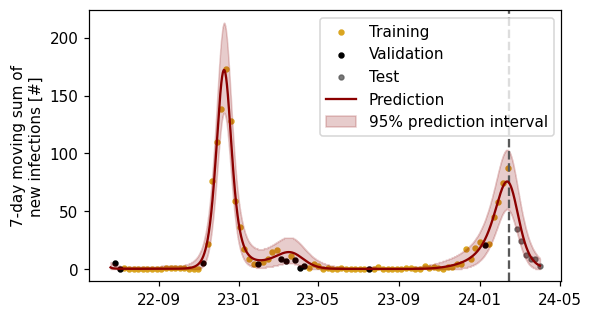

In [18]:
fig1

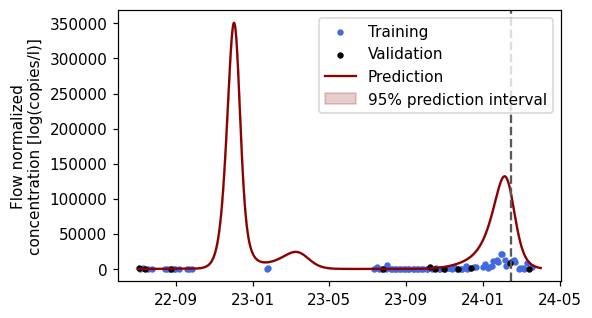

In [19]:
fig2

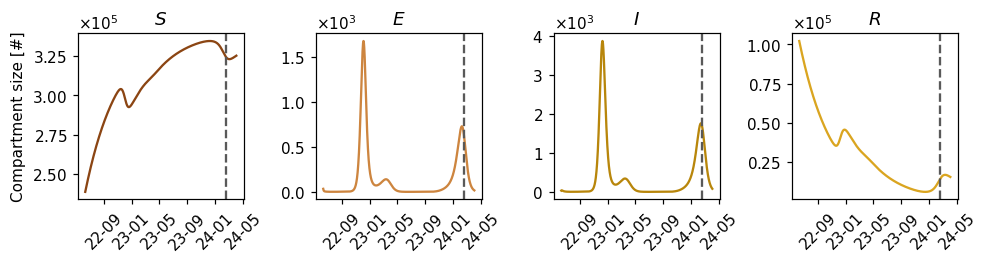

In [20]:
two_phase_integrative_ude.plot_SEIR_prediction(model, data["t_all"], data["dates_all"], phase_cut_date)

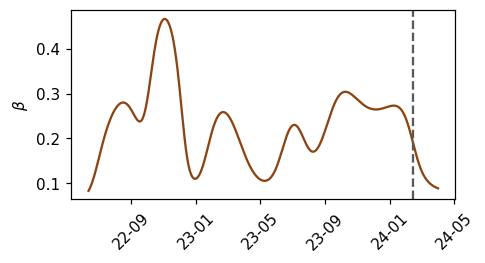

In [21]:
two_phase_integrative_ude.plot_beta_prediction(model, data["t_all"], data["dates_all"], phase_cut_date)

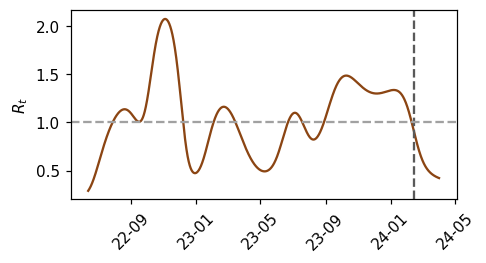

In [22]:
two_phase_integrative_ude.plot_effective_reproduction_number(model, data["t_all"], data["dates_all"], phase_cut_date)

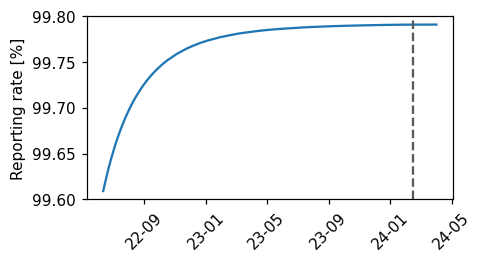

In [23]:
two_phase_integrative_ude.plot_underreporting(model, data["t_all"], data["t_phase_1"], data["dates_all"], phase_cut_date)

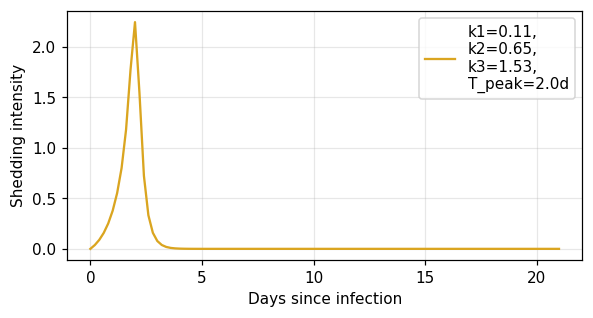

In [24]:
two_phase_integrative_ude.plot_shedding_curve(model)

In [22]:
import jax.random as jr
import jax.numpy as jnp
import jax
import sys
import os, pathlib, tempfile
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import optimization_utils

import optuna
import gc
from datetime import datetime  # added for timestamping saves

/home/iru-mls/Documents/repositories/ww_bonn_jax/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
import jax.random as jr
import jax.numpy as jnp
import jax
from jax.scipy.special import gammaln

import sys
import os
import json

from optimization import optimization_utils
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import model_definition.two_phase_integrative_ude as two_phase_integrative_ude
import data.data_utils_integrative_model as data_utils_integrative_model
import model_definition.model_utils as model_utils

import equinox as eqx
import pandas as pd
import argparse
import optuna
import pathlib

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from optuna.visualization import (
    plot_param_importances, 
)
import warnings
warnings.filterwarnings('ignore')

In [26]:
base_config = {
        # General settings
        "seed": 1,  # random seed

        # data selection settings
        "data_kwargs": {
            "town": "Bonn", 
            "pathogen": "influenza"
        },
        
        "dt": 0.2,
        "T_max": 25, # dummy value
}

base_config["phase_cut_date"] = "2024-02-14"
data = optimization_utils.two_phase_integrative_model_load_data(base_config)

base_config["E0"] = data["population_size"] * 1e-4
base_config["I0"] = data["population_size"] * 1e-4


In [29]:
model_path = pathlib.Path(f"/home/iru-mls/marvin/ww_bonn_jax/Bonn_influenza/optuna_best_{base_config['phase_cut_date']}")


def build_config_from_saved(base_config, hparams: dict) -> dict:
    """Merge base config from integrative_ude_optuna.py with saved trial params."""
    import copy

    base = copy.deepcopy(base_config)
    base.update(hparams)
    # Keep solver kwargs consistent
    if "solver_kwargs" not in base:
        base["solver_kwargs"] = {
            "rtol": hparams.get("rtol"),
            "atol": hparams.get("atol"),
        }
    else:
        base["solver_kwargs"]["rtol"] = hparams.get(
            "rtol", base["solver_kwargs"].get("rtol")
        )
        base["solver_kwargs"]["atol"] = hparams.get(
            "atol", base["solver_kwargs"].get("atol")
        )
    return base

with open(f"{model_path}/hparams.json") as f:
    hparams = json.load(f)

# Merge with base config from your Optuna script
config = build_config_from_saved(base_config, hparams)

# Generate dataset
data = optimization_utils.two_phase_integrative_model_load_data(config)
config["R0"] = config["R0_multiplier"]*data["population_size"]

In [31]:
model = two_phase_integrative_ude.InfluenzaIntegrativeModel(
    width_size=config["width_size"],
    depth=config["depth"],
    activation=model_utils.activation_fct_mapper[config["activation"]],
    n_freqs=config["n_freqs"],
    t_scale=data["t_scale"],
    population_size=data["population_size"],
    E0_init=config["E0"],
    I0_init=config["I0"],
    R0_init=config["R0"],
    solver=model_utils.solver_mapper[config["solver"]],
    solver_kwargs=config["solver_kwargs"],
    k1_init=config["k1_init"],
    k2_init=config["k2_init"],
    k3_init=config["k3_init"],
    T_peak_init=config["T_peak_init"],
    T_max=config["T_max"],
    dt = config["dt"],
    key=jr.key(config["seed"]),
    init_par_vmr=config.get("init_par_vmr", 1.0),
    init_sigma_C=config.get("init_sigma_C", 1.0),
    reporting_delay=config.get("reporting_delay", 3)) # days, delay between infection and reporting

model = eqx.tree_deserialise_leaves(f"{model_path}/model.eqx", model)

In [35]:
pred_conc, I_new_7d_pred = model(data["t_all"], data["t_phase_1"])

In [41]:
pred2, _ = model.predict_without_log_transform(data["t_all"], data["t_phase_1"])

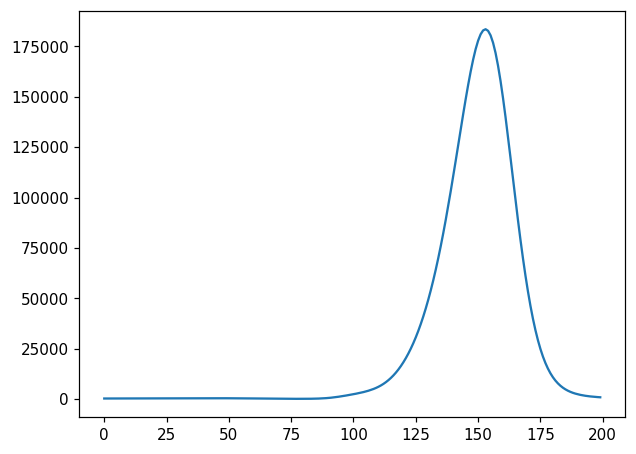

In [55]:
plt.plot(pred2[:200])

In [43]:
pred2

Array([363.54028 , 364.25778 , 365.20847 , ...,  38.771816,  37.397144,
        36.08911 ], dtype=float32)

In [39]:
jnp.exp(pred_conc)

Array([363.54034 , 364.25784 , 365.2085  , ...,  38.771816,  37.39715 ,
        36.08911 ], dtype=float32)

In [40]:
data["conc_train"]

array([  366.0502412 ,     0.        ,   499.16199318,   215.45580466,
           0.        ,     0.        ,   303.8692967 ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,   422.63972147,  1389.79347537,
           0.        ,     0.        ,     0.        ,     0.        ,
        2984.0551001 ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,  1647.81204204,
         210.93328174,     0.        ,   625.45276699,     0.        ,
           0.        ,     0.        ,     0.        ,   442.45147581,
         947.412407  ,     0.        ,     0.        ,     0.        ,
           0.        ,  1894.27143622,  1013.75597985,  1603.20460495,
      

In [34]:
data.keys()

dict_keys(['t_all', 't_all_idx', 't_phase_1', 't_mask_I_train', 't_mask_I_val', 't_mask_I_test', 't_mask_I_all', 'I_train', 'I_val', 'obs_dates_phase_2', 'I_test', 'I_all', 'dates_all', 'I_dates_train', 'I_dates_val', 'conc_train', 'conc_val', 'eval_conc', 't_mask_conc_train', 't_mask_conc_val', 't_mask_conc_all', 'conc_dates_train', 'conc_dates_val', 'conc_dates_test', 'eval_conc_dates', 'test_conc', 'population_size', 't_scale', 'town', 'n_tests_train', 'n_tests_val', 'n_tests_test', 'n_tests', 'pos_tests_train', 'pos_tests_val', 'pos_tests_test', 'pos_tests', 'prevalence_dates_train', 'prevalence_dates_val', 'prevalence_dates_test', 't_mask_prev_train', 't_mask_prev_val', 't_mask_prev_test', 't_mask_prev_all'])

In [44]:
fig1, fig2 = two_phase_integrative_ude.plot_model_zero_inflated_noise_model(model, data["t_all"], data["t_phase_1"], phase_cut_date,
               data["I_dates_train"], data["I_train"],
               data["I_dates_val"], data["I_val"],
               data["obs_dates_phase_2"], data["I_test"], data["dates_all"],
               data["conc_dates_train"], data["conc_train"],
               data["conc_dates_val"], data["conc_val"], data["t_all_idx"])

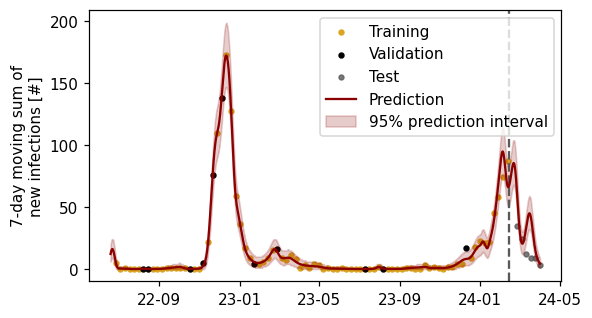

In [45]:
fig1

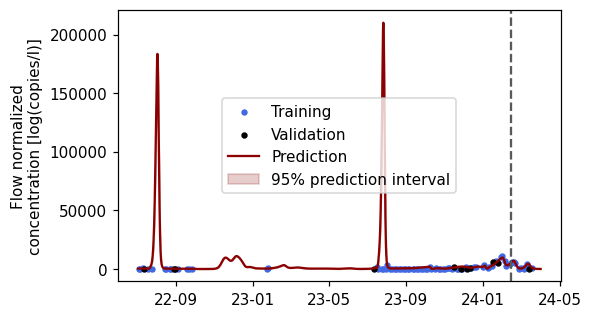

In [46]:
fig2

In [48]:

def plain_negll(model, t_all, t_phase_1, t_mask_ids_I, t_mask_ids_conc, obs_cases, obs_conc):
    pi_C = jax.nn.sigmoid(model.logit_pi_C) # probability of observing a zero in the concentration measurements
    
    # Forward pass
    pred_conc, I_new_7d_pred = model(t_all, t_phase_1)

    # Select observed timestamps from predictions
    I_new_7d_sel = I_new_7d_pred[t_mask_ids_I]
    conc_sel     = pred_conc[t_mask_ids_conc]

    # Masks to ignore NaNs from 7-day window/reporting delay and missing obs
    I_valid = (~jnp.isnan(I_new_7d_sel))
    C_valid = (~jnp.isnan(conc_sel))

    pred_I_masked = jnp.where(I_valid, I_new_7d_sel, 0.0)
    obs_I_masked  = jnp.where(I_valid, obs_cases, 0.0)
    pred_C_masked = jnp.where(C_valid, conc_sel, 0.0)
    obs_C_masked  = jnp.where(C_valid, obs_conc, 0.0)

    zero_mask = C_valid & (obs_conc == 0.0) 
    pos_mask  = C_valid & (obs_conc >  0.0)
    
    # Pull σ from the model
    # sigma_I = jnp.exp(model.log_sigma_I)
    sigma_C = jnp.exp(model.log_sigma_C)
    vmr_I = 1.0 + jax.nn.softplus(model.par_vmr)

    I_mask = jnp.sum(jnp.where(I_valid, 1, 0))
    C_mask = jnp.sum(jnp.where(C_valid, 1, 0))

    # ----- Negative binomial NLL for case counts -----
    # Convert (mean, VMR) -> (r, p)
    eps = 1e-8
    # p = 1 / VMR  (independent of μ)
    p_nb = jnp.clip(1.0 / vmr_I, eps, 1.0 - eps)
    # r = μ / (VMR - 1)
    r_nb = jnp.clip(pred_I_masked / jnp.maximum(vmr_I - 1.0, eps), eps, 1e12)

    # Count data (assumed integer non-negative)
    k = jnp.clip(obs_I_masked, 0.0, 1e12)

    # log PMF: log C(k+r-1, k) + r log p + k log(1-p)
    logpmf_nb = (
        gammaln(k + r_nb) - gammaln(r_nb) - gammaln(k + 1.0)
        + r_nb * jnp.log(p_nb) + k * jnp.log1p(-p_nb)
    )

    nll_I = -jnp.sum(jnp.where(I_valid, logpmf_nb, 0.0))

    # zero inflated log normal for concentration data
    eps = 1e-12
    nll_zero = jnp.where(zero_mask, -jnp.log(jnp.clip(pi_C, eps, 1.0 - eps)), 0.0)

    nlogpdf_lognorm = 0.5 * ((pred_C_masked - jnp.log(obs_C_masked)) / sigma_C) ** 2 + 0.5 * jnp.log(2 * jnp.pi * sigma_C ** 2) * C_mask # this is equivalent to log normal noise model (assuming that the data doesn't change, i.e. up to a constant value) 
    nll_pos  = jnp.where(pos_mask,  -jnp.log1p(-jnp.clip(pi_C, eps, 1.0 - eps)) + nlogpdf_lognorm, 0.0)
    nll_C = jnp.sum(nll_zero + nll_pos)

    any_inf = jnp.any(jnp.isinf(I_new_7d_sel)) | jnp.any(jnp.isinf(conc_sel))
    any_nan = jnp.isnan(nll_I / jnp.maximum(I_mask, 1)) | jnp.isnan(nll_C / jnp.maximum(C_mask, 1))
    return (nll_I / I_mask), (nll_C / C_mask) # + config.get("reg_norm")*model.beta_regularization_loss(ts=t_all, mode=config.get("regularization_mode"))) + config.get("underreporting_reg_norm", 0)*model.underreporting_regularization_loss(ts=t_all, mode=config.get("underreporting_regularization_mode", "None"))


In [49]:
nll_I, nll_C = plain_negll(model, t_all, t_phase_1, t_mask_ids_I, t_mask_ids_conc, obs_cases, obs_conc)

In [50]:
nll_I

Array(1.5368189, dtype=float32)

In [51]:
nll_C

Array(-31.930012, dtype=float32)